# Mackenzie River Outflow correlation time series

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
from scipy.stats import t
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:33997")
client

<Client: 'tcp://127.0.0.1:33997' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

# open RHOAnoma zarr store - [fraction of sea ice, 0 to 1]
RHOAnoma_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_DAILY.ZARR/', s3_options)

In [7]:
# remove 2021 to since we only have January and a few days in Feb that year
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

# add reference density to density anomaly (RHOAnoma)
rhoConst = 1027.5 # reference density
density_day = RHOAnoma_zarr_day.RHOAnoma.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1) + rhoConst

In [8]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

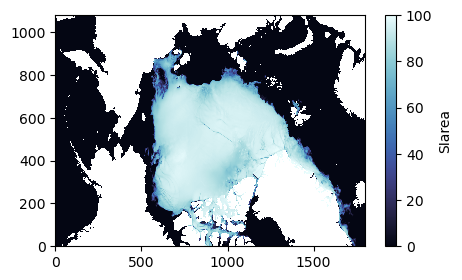

In [9]:
ice_day.sel(time='2020-09-20').isel(time=0).plot(cmap=cmocean.cm.ice,vmin=0,vmax=100,figsize=[5,3]);
plt.title("")
plt.ylabel("")
plt.xlabel("");

In [10]:
# cut out beaufort sea box
SSS_beaufort = salt_day.isel(k=0,i=slice(450,750),j=slice(100,400))
SST_beaufort = theta_day.isel(k=0,i=slice(450,750),j=slice(100,400))
SI_beaufort = ice_day.isel(i=slice(450,750),j=slice(100,400))
rho_beaufort = density_day.isel(i=slice(450,750),j=slice(100,400))
land_beaufort_mask = HH_grid_land.isel(i=slice(450,750),j=slice(100,400))

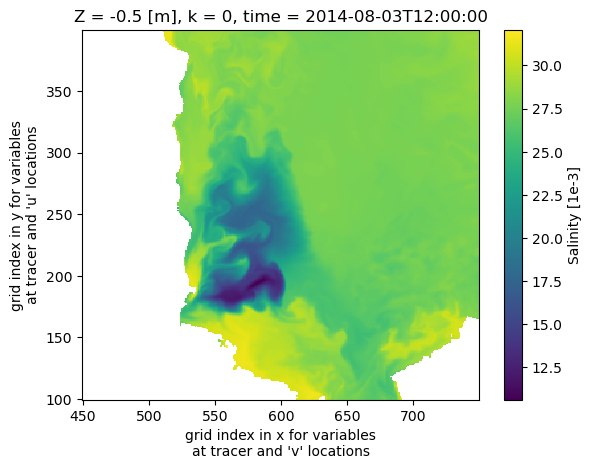

In [11]:
SSS_beaufort.isel(time=200).plot();

### Calculate delta rho

In [12]:
print(rho_beaufort.isel(k=0).Z.values)
print(rho_beaufort.isel(k=10).Z.values)
print(rho_beaufort.isel(k=21).Z.values)

-0.5
-21.125
-99.37


In [13]:
# calculate delta rho
delta_rho20 = rho_beaufort.isel(k=10) - rho_beaufort.isel(k=0)
delta_rho100 = rho_beaufort.isel(k=21) - rho_beaufort.isel(k=0)

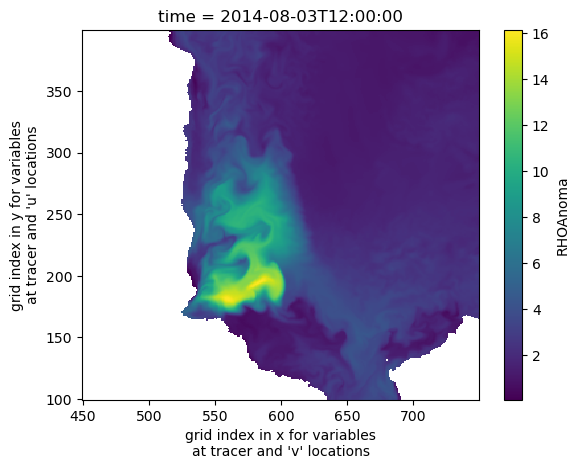

In [14]:
# select only Beaufort region
delta_rho20.isel(time=200).plot();

### Plot variables within selected box

In [15]:
# rotate 90 degrees counterclockwise
si_flip = xr.DataArray(np.rot90((SI_beaufort.sel(time='2020-09-20').isel(time=0)),3,axes=[0,1]), dims=['i','j'])
land_mask_flip = xr.DataArray(np.rot90(land_beaufort_mask,3,axes=[0,1]), dims=['i','j'])

# temp
temp_beaufort_flip = xr.DataArray(np.rot90(SST_beaufort.sel(time='2020-09-20').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# salinity
salt_beaufort_flip = xr.DataArray(np.rot90(SSS_beaufort.sel(time='2020-09-20').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# delta rho
delta_rho20_flip = xr.DataArray(np.rot90(delta_rho20.sel(time='2020-09-20').isel(time=0),3,axes=[0,1]), dims=['i','j'])
delta_rho100_flip = xr.DataArray(np.rot90(delta_rho100.sel(time='2020-09-20').isel(time=0),3,axes=[0,1]), dims=['i','j'])

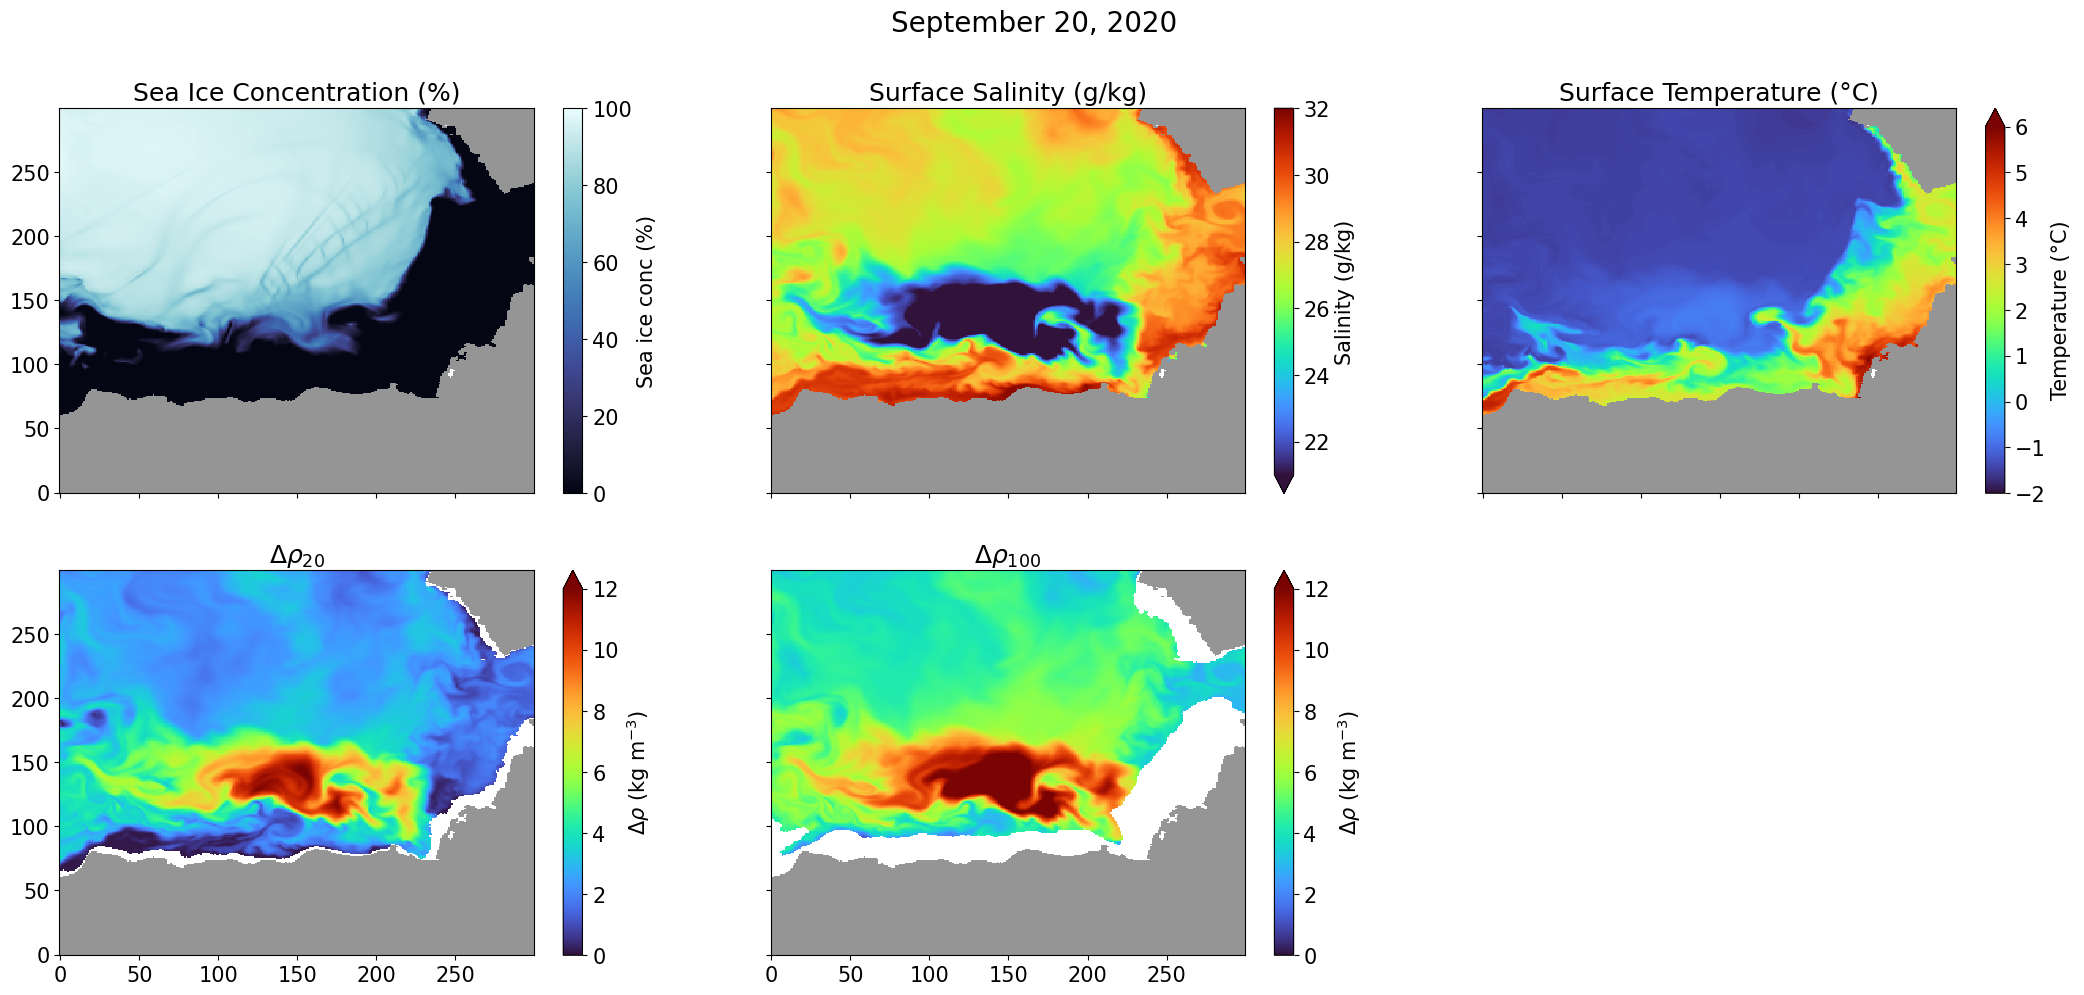

In [16]:
plt.rcParams.update({'font.size': 15})
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2,3,figsize=[26,11],sharey=True,sharex=True)

si_flip.plot(ax=ax1,cmap=cmocean.cm.ice,vmin=0,vmax=100,cbar_kwargs={'label': "Sea ice conc (%)"});
salt_beaufort_flip.plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
temp_beaufort_flip.plot(ax=ax3,cmap='turbo',vmin=-2,vmax=6,cbar_kwargs={'label': "Temperature (°C)"});
delta_rho20_flip.plot(ax=ax4,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});
delta_rho100_flip.plot(ax=ax5,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});

# salt_beaufort_flip.plot.contour(ax=ax2,levels=[30.25],colors='k',linestyles='dashed');
# beaufort_ocean_ds.where(SI_day<15,np.nan).temperature.isel(k=0).plot.contour(ax=ax3,levels=[6.5],colors='k',linestyles='dashed');

for ax in (ax1,ax2,ax3,ax4,ax5):
    # ax.axhline(y=200,color='r');
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("")
    ax.set_xlabel("")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Surface Temperature (°C)");
ax4.set_title(r"$\Delta\rho_{20}$");
ax5.set_title(r"$\Delta\rho_{100}$");

ax6.set_axis_off()

plt.suptitle("September 20, 2020",y=0.97,fontsize=20);

Mask out sea ice for each day, then compute correlation coefficients between SSS and delta rho for each day and plot time series

### Mask out SI for each day

In [17]:
# check shape of vars
print(SSS_beaufort.shape)
print(SST_beaufort.shape)
print(delta_rho20.shape)
print(delta_rho100.shape)

(2543, 300, 300)
(2543, 300, 300)
(2543, 300, 300)
(2543, 300, 300)


In [18]:
# select just one year of data
SSS_2019 = SSS_beaufort.sel(time="2019")
SST_2019 = SST_beaufort.sel(time="2019")
SI_2019 = SI_beaufort.sel(time="2019")
delta_rho20_2019 = delta_rho20.sel(time="2019")
delta_rho100_2019 = delta_rho100.sel(time="2019")

In [19]:
# mask grid cells with >15% ice cover
SSS_2019_icefree = SSS_2019.where(SI_2019<15)
SST_2019_icefree = SST_2019.where(SI_2019<15)
delta_rho20_2019_icefree = delta_rho20_2019.where(SI_2019<15)
delta_rho100_2019_icefree = delta_rho100_2019.where(SI_2019<15)

In [20]:
# rotate 90 degrees counterclockwise
si_flip = xr.DataArray(np.rot90((SI_2019.sel(time='2019-08-15').isel(time=0)),3,axes=[0,1]), dims=['i','j'])
land_mask_flip = xr.DataArray(np.rot90(land_beaufort_mask,3,axes=[0,1]), dims=['i','j'])

# temp
temp_beaufort_flip = xr.DataArray(np.rot90(SST_2019_icefree.sel(time='2019-08-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# salinity
salt_beaufort_flip = xr.DataArray(np.rot90(SSS_2019_icefree.sel(time='2019-08-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# delta rho
delta_rho20_flip = xr.DataArray(np.rot90(delta_rho20_2019_icefree.sel(time='2019-08-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])
delta_rho100_flip = xr.DataArray(np.rot90(delta_rho100_2019_icefree.sel(time='2019-08-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

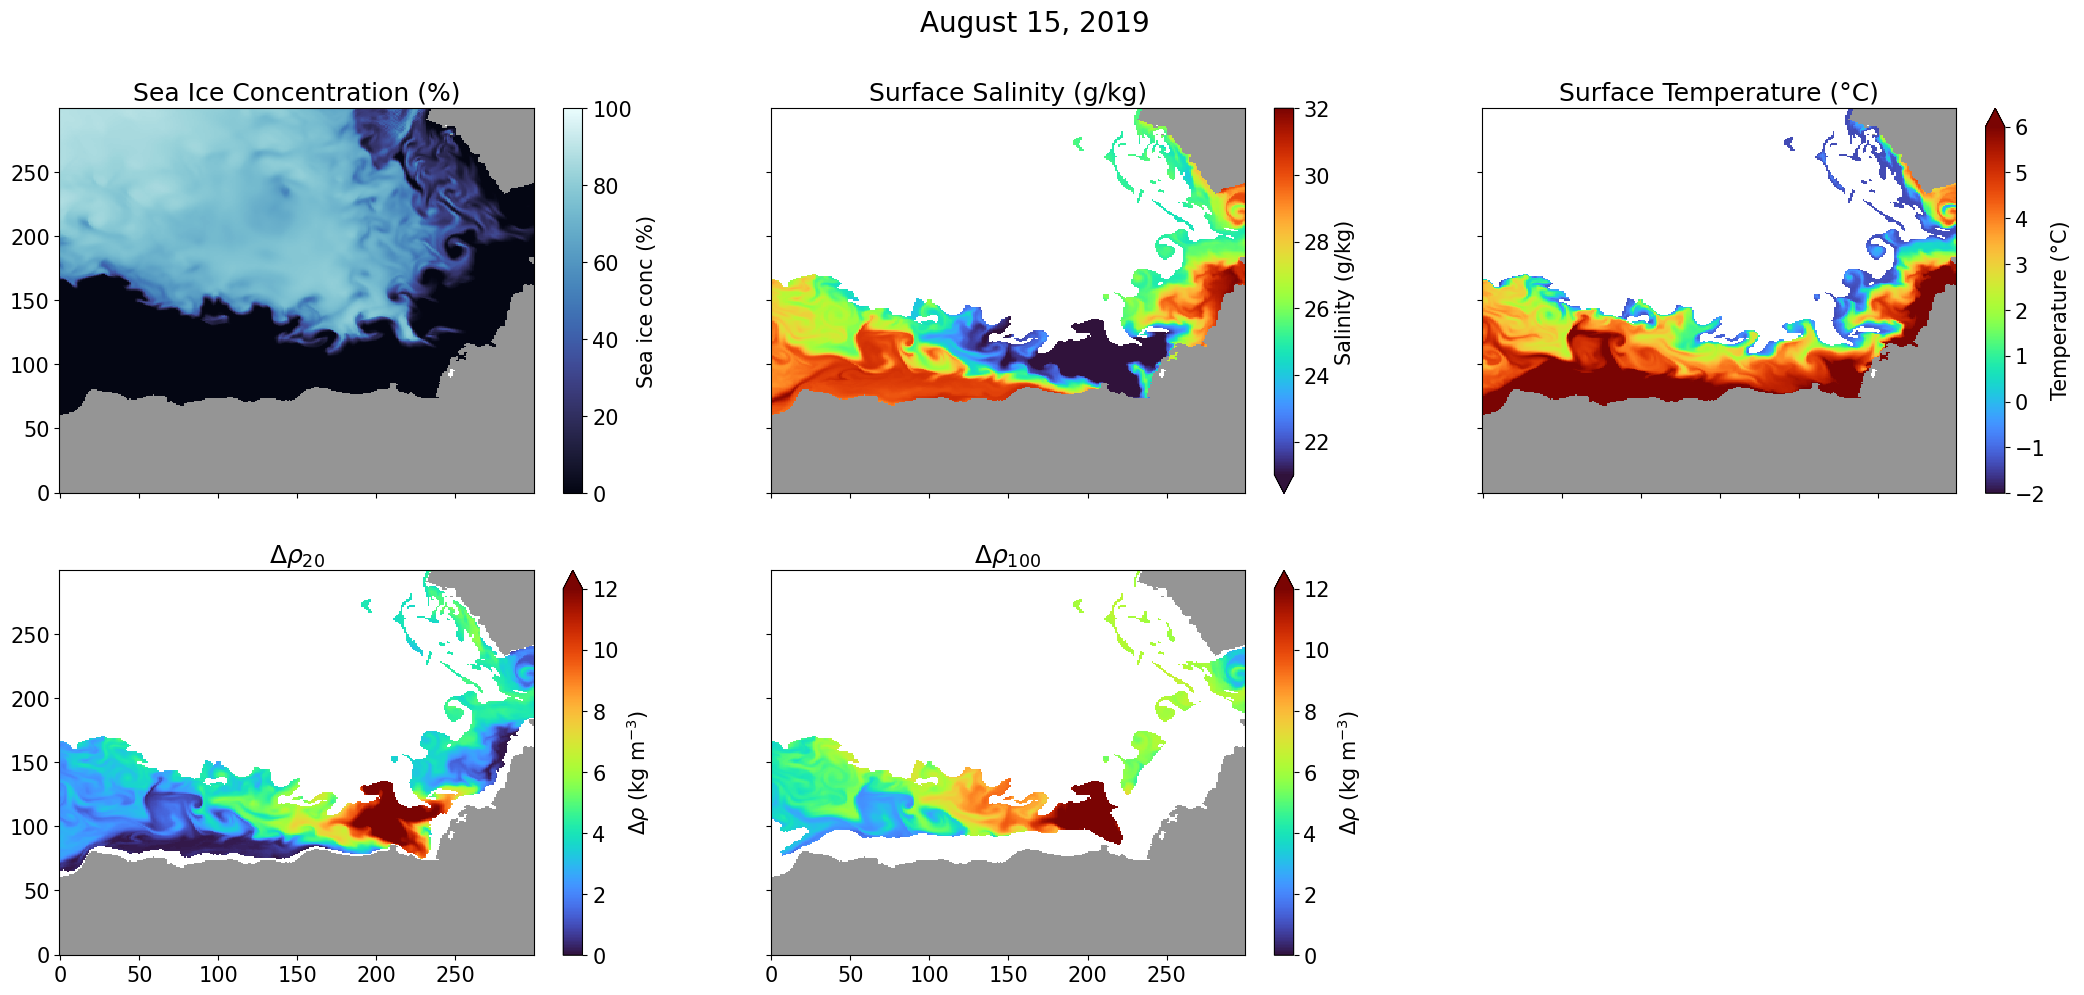

In [21]:
plt.rcParams.update({'font.size': 15})
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2,3,figsize=[26,11],sharey=True,sharex=True)

si_flip.plot(ax=ax1,cmap=cmocean.cm.ice,vmin=0,vmax=100,cbar_kwargs={'label': "Sea ice conc (%)"});
salt_beaufort_flip.plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
temp_beaufort_flip.plot(ax=ax3,cmap='turbo',vmin=-2,vmax=6,cbar_kwargs={'label': "Temperature (°C)"});
delta_rho20_flip.plot(ax=ax4,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});
delta_rho100_flip.plot(ax=ax5,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});

# salt_beaufort_flip.plot.contour(ax=ax2,levels=[30.25],colors='k',linestyles='dashed');
# beaufort_ocean_ds.where(SI_day<15,np.nan).temperature.isel(k=0).plot.contour(ax=ax3,levels=[6.5],colors='k',linestyles='dashed');

for ax in (ax1,ax2,ax3,ax4,ax5):
    # ax.axhline(y=200,color='r');
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("")
    ax.set_xlabel("")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Surface Temperature (°C)");
ax4.set_title(r"$\Delta\rho_{20}$");
ax5.set_title(r"$\Delta\rho_{100}$");

ax6.set_axis_off()

plt.suptitle("August 15, 2019",y=0.97,fontsize=20);

### Compute spatial correlations for 2019

In [22]:
def sig_corr(corr_da, n):
    """
    Determine which correlations are statistically significant
    Mask insignificant values in provided array and return only signficant values

    n : sample size
    corr_da : correlation coefficients
    """
    
    # compute the t-statistic
    t_stat = corr_da * np.sqrt((n - 2) / (1 - corr_da**2))

    # compute p-values using the survival function (1 - CDF)
    p_values = 2 * t.sf(np.abs(t_stat), df=n - 2)

    # determine significance at alpha=0.05
    alpha = 0.05
    # mask non-significant correlations
    corr_significant = corr_da.where(p_values < alpha)
    
    return corr_significant

In [95]:
corr_20minus0 = xr.corr(SSS_2019_icefree, delta_rho20_2019_icefree, dim=['i','j'])

In [97]:
significant_corr_20minus0 = sig_corr(corr_20minus0, len(SSS_2019_icefree['time']))

In [121]:
# calculate SI cover for the beaufort sea box
# select grid cell area
beaufort_area = HH_grid.rAc.isel(i=slice(450,750),j=slice(100,400)).load()
beaufort_area_total_ocean = (HH_grid.rAc.isel(i=slice(450,750),j=slice(100,400))*HH_grid.hFacC.isel(k=0)).sum(dim=['j','i']).load()

# calculate sea ice area
SIcover_beaufort_percent = (SI_2019*beaufort_area).sum(dim=['j','i']) / beaufort_area_total_ocean

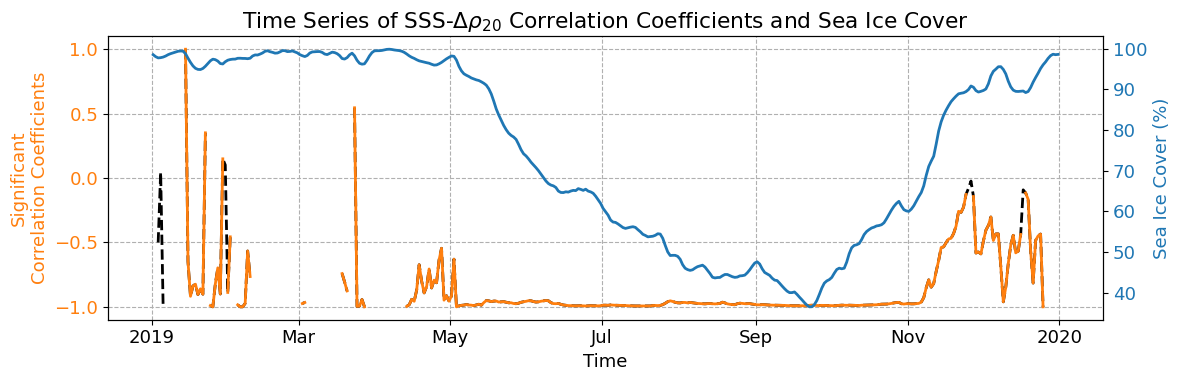

In [129]:
# Create a plot of coeff and sea ice cover
plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots(figsize=(12, 4))

# Plot correlation coefficients on the primary axis
corr_20minus0.plot(ax=ax1, color='k', linestyle='dashed', label='Correlation Coefficients', linewidth=2)
significant_corr_20minus0.plot(ax=ax1, color='tab:orange', label='Correlation Coefficients', linewidth=2)
ax1.set_xlabel('Time')
ax1.set_ylabel('Significant\nCorrelation Coefficients', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')
ax1.grid(linestyle='dashed')

# Create secondary axis for sea ice area
ax2 = ax1.twinx()  # Create a second y-axis
SIcover_beaufort_percent.plot(ax=ax2, color='tab:blue', label='Sea Ice Cover (%)', linewidth=2)
ax2.set_ylabel('Sea Ice Cover (%)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Add a title and show the plot
ax1.set_title(r'Time Series of SSS-$\Delta\rho_{20}$ Correlation Coefficients and Sea Ice Cover')
ax2.set_title("")
fig.tight_layout()

### Plot an example from December 2019 when correlation breaks down

In [130]:
# rotate 90 degrees counterclockwise
si_flip = xr.DataArray(np.rot90((SI_2019.sel(time='2019-12-15').isel(time=0)),3,axes=[0,1]), dims=['i','j'])
land_mask_flip = xr.DataArray(np.rot90(land_beaufort_mask,3,axes=[0,1]), dims=['i','j'])

# temp
temp_beaufort_flip = xr.DataArray(np.rot90(SST_2019_icefree.sel(time='2019-12-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# salinity
salt_beaufort_flip = xr.DataArray(np.rot90(SSS_2019_icefree.sel(time='2019-12-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

# delta rho
delta_rho20_flip = xr.DataArray(np.rot90(delta_rho20_2019_icefree.sel(time='2019-12-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])
delta_rho100_flip = xr.DataArray(np.rot90(delta_rho100_2019_icefree.sel(time='2019-12-15').isel(time=0),3,axes=[0,1]), dims=['i','j'])

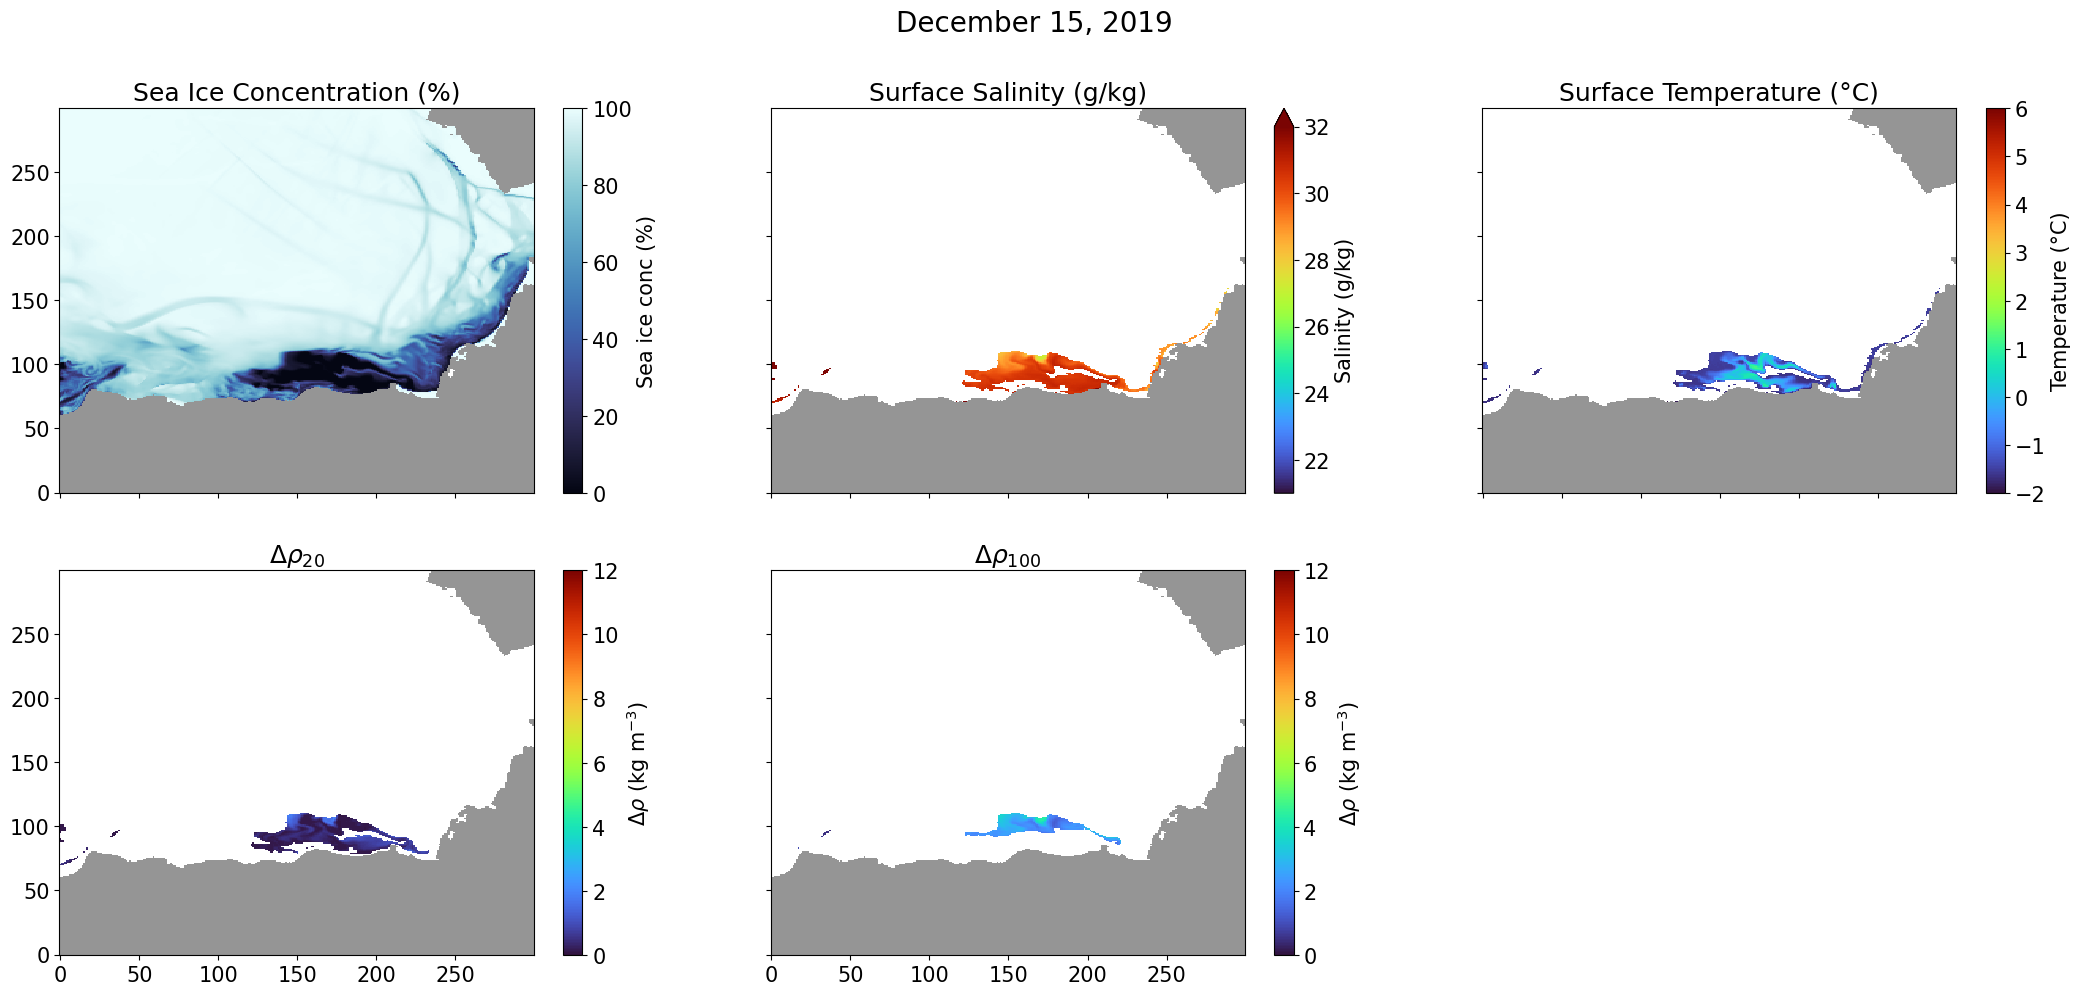

In [131]:
plt.rcParams.update({'font.size': 15})
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2,3,figsize=[26,11],sharey=True,sharex=True)

si_flip.plot(ax=ax1,cmap=cmocean.cm.ice,vmin=0,vmax=100,cbar_kwargs={'label': "Sea ice conc (%)"});
salt_beaufort_flip.plot(ax=ax2,cmap='turbo',vmin=21,vmax=32,cbar_kwargs={'label': "Salinity (g/kg)"});
temp_beaufort_flip.plot(ax=ax3,cmap='turbo',vmin=-2,vmax=6,cbar_kwargs={'label': "Temperature (°C)"});
delta_rho20_flip.plot(ax=ax4,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});
delta_rho100_flip.plot(ax=ax5,cmap='turbo',vmin=0,vmax=12,cbar_kwargs={'label': r"$\Delta\rho$ (kg m$^{-3}$)"});

# salt_beaufort_flip.plot.contour(ax=ax2,levels=[30.25],colors='k',linestyles='dashed');
# beaufort_ocean_ds.where(SI_day<15,np.nan).temperature.isel(k=0).plot.contour(ax=ax3,levels=[6.5],colors='k',linestyles='dashed');

for ax in (ax1,ax2,ax3,ax4,ax5):
    # ax.axhline(y=200,color='r');
    land_mask_flip.plot(ax=ax,cmap='Greys',add_colorbar=False)
    ax.set_ylabel("")
    ax.set_xlabel("")

ax1.set_title("Sea Ice Concentration (%)")
ax2.set_title("Surface Salinity (g/kg)");
ax3.set_title("Surface Temperature (°C)");
ax4.set_title(r"$\Delta\rho_{20}$");
ax5.set_title(r"$\Delta\rho_{100}$");

ax6.set_axis_off()

plt.suptitle("December 15, 2019",y=0.97,fontsize=20);

### Compute spatial correlations for all 7 years

In [23]:
# check shape of vars
print(SSS_beaufort.shape)
print(SST_beaufort.shape)
print(delta_rho20.shape)
print(delta_rho100.shape)
print(SI_beaufort.shape)

(2543, 300, 300)
(2543, 300, 300)
(2543, 300, 300)
(2543, 300, 300)
(2543, 300, 300)


In [24]:
# mask grid cells with >15% ice cover
SSS_icefree = SSS_beaufort.where(SI_beaufort<15)
SST_icefree = SST_beaufort.where(SI_beaufort<15)
delta_rho20_icefree = delta_rho20.where(SI_beaufort<15)
delta_rho100_icefree = delta_rho100.where(SI_beaufort<15)

In [25]:
corr_20minus0 = xr.corr(SSS_icefree, delta_rho20_icefree, dim=['i','j'])

In [26]:
significant_corr_20minus0 = sig_corr(corr_20minus0, len(SSS_icefree['time']))

In [27]:
# calculate SI cover for the beaufort sea box
# select grid cell area
beaufort_area = HH_grid.rAc.isel(i=slice(450,750),j=slice(100,400)).load()
beaufort_area_total_ocean = (HH_grid.rAc.isel(i=slice(450,750),j=slice(100,400))*HH_grid.hFacC.isel(k=0)).sum(dim=['j','i']).load()

# calculate sea ice area
SIcover_beaufort_total = (SI_beaufort*beaufort_area).sum(dim=['j','i']) / beaufort_area_total_ocean

# fix two empty days from the dataset
SIcover_beaufort_total.loc['2014-04-24'] = np.nan
SIcover_beaufort_total.loc['2015-04-09'] = np.nan

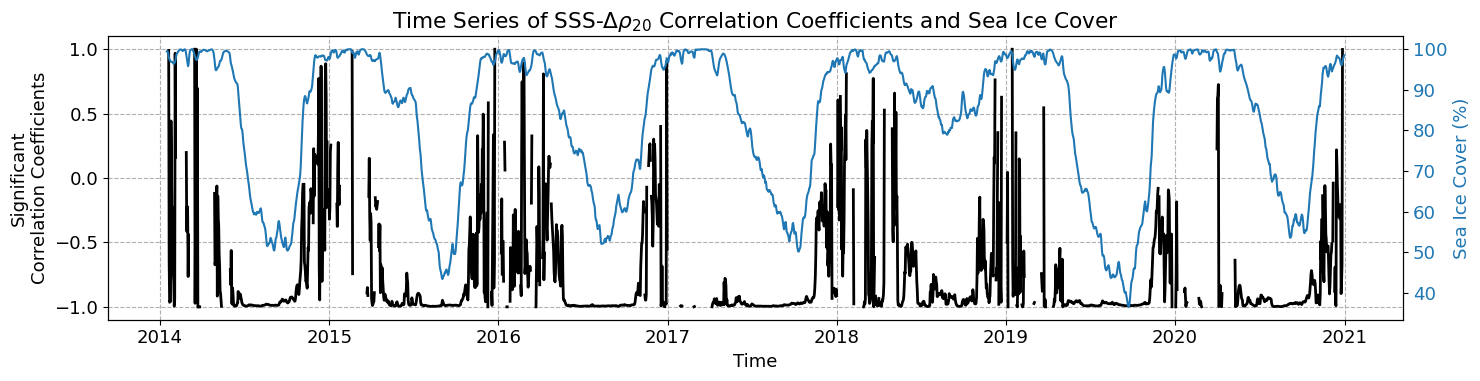

In [164]:
# Create a plot of coeff and sea ice cover
plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots(figsize=(15, 4))

# Plot correlation coefficients on the primary axis
# corr_20minus0.plot(ax=ax1, color='k', linestyle='solid', label='Correlation Coefficients', linewidth=1.5)
significant_corr_20minus0.plot(ax=ax1, color='k', label='Correlation Coefficients', linewidth=2)
ax1.set_xlabel('Time')
ax1.set_ylabel('Significant\nCorrelation Coefficients', color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.grid(linestyle='dashed')

# Create secondary axis for sea ice area
ax2 = ax1.twinx()  # Create a second y-axis
SIcover_beaufort_total.plot(ax=ax2, color='tab:blue', label='Sea Ice Cover (%)', linewidth=1.5)
ax2.set_ylabel('Sea Ice Cover (%)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Add a title and show the plot
ax1.set_title(r'Time Series of SSS-$\Delta\rho_{20}$ Correlation Coefficients and Sea Ice Cover')
ax2.set_title("")
fig.tight_layout()

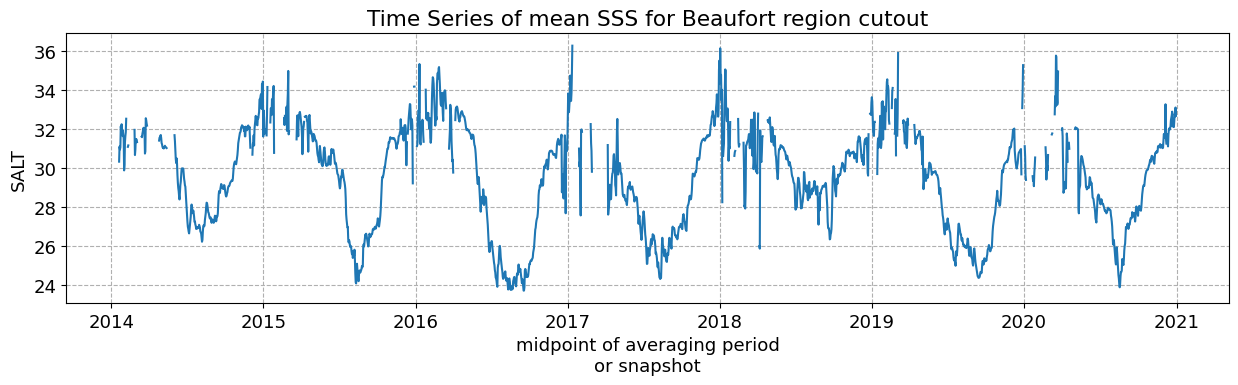

In [147]:
# plot time series of SSS
plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots(figsize=(15, 3.5))

SSS_icefree.mean(dim=['i','j']).plot(ax=ax1)
ax1.grid(linestyle='dashed')

ax1.set_title(r'Time Series of mean SSS for Beaufort region cutout');

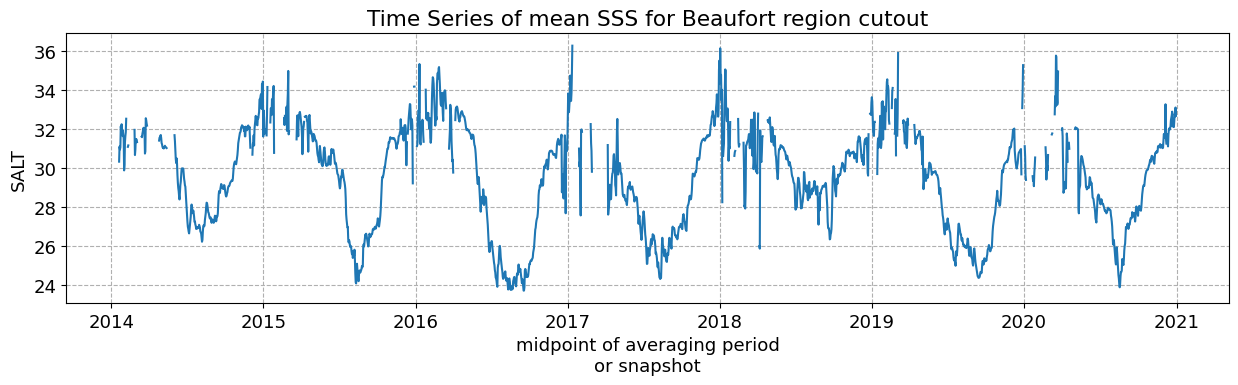

In [147]:
# plot time series of SSS
plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots(figsize=(15, 3.5))

SSS_icefree.mean(dim=['i','j']).plot(ax=ax1)
ax1.grid(linestyle='dashed')

ax1.set_title(r'Time Series of mean SSS for Beaufort region cutout');

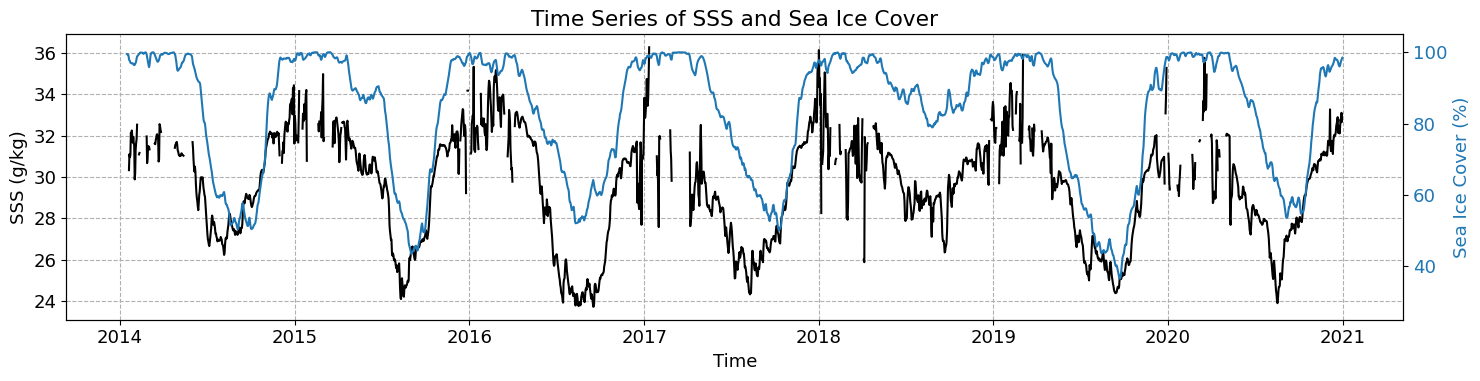

In [163]:
# Create a plot of coeff and sea ice cover
plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots(figsize=(15, 4))

# Plot correlation coefficients on the primary axis
# corr_20minus0.plot(ax=ax1, color='k', linestyle='solid', label='Correlation Coefficients', linewidth=1.5)
SSS_icefree.mean(dim=['i','j']).plot(ax=ax1,color='k', linewidth=1.5)
ax1.set_xlabel('Time')
ax1.set_ylabel('SSS (g/kg)', color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.grid(linestyle='dashed')

# Create secondary axis for sea ice area
ax2 = ax1.twinx()  # Create a second y-axis
SIcover_beaufort_total.plot(ax=ax2, color='tab:blue', label='Sea Ice Cover (%)', linewidth=1.5)
ax2.set_ylabel('Sea Ice Cover (%)', color='tab:blue')
ax2.set_ylim(25,105)
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Add a title and show the plot
ax1.set_title(r'Time Series of SSS and Sea Ice Cover')
ax2.set_title("")
fig.tight_layout()

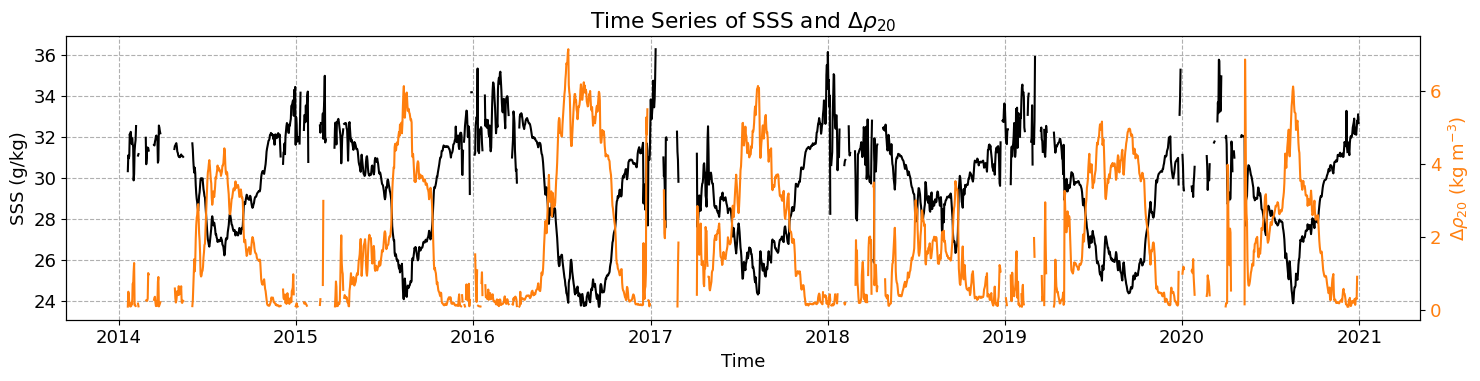

In [30]:
# Create a plot of coeff and sea ice cover
plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots(figsize=(15, 4))

# Plot correlation coefficients on the primary axis
# corr_20minus0.plot(ax=ax1, color='k', linestyle='solid', label='Correlation Coefficients', linewidth=1.5)
SSS_icefree.mean(dim=['i','j']).plot(ax=ax1,color='k', linewidth=1.5)
ax1.set_xlabel('Time')
ax1.set_ylabel('SSS (g/kg)', color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.grid(linestyle='dashed')

# Create secondary axis for delta rho
ax2 = ax1.twinx()  # Create a second y-axis
delta_rho20_icefree.mean(dim=['i','j']).plot(ax=ax2, color='tab:orange', linewidth=1.5)
ax2.set_ylabel(r'$\Delta\rho_{20}$ (kg m$^{-3}$)', color='tab:orange')
# ax2.set_ylim(25,105)
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Add a title and show the plot
ax1.set_title(r'Time Series of SSS and $\Delta\rho_{20}$')
ax2.set_title("")
fig.tight_layout()